<a href="https://colab.research.google.com/github/DarkLyng/Challenge-TelecomX_P2/blob/main/Telecom_X_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. 🛠️ Preparación de los Datos**

In [ ]:
#Bibliotecas

import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

In [ ]:
datos = pd.read_csv("/content/df_normalizado.csv")
datos

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.60,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,...,0,0,1,0,0,One year,0,Mailed check,55.15,742.90
7028,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70
7029,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,...,1,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75
7030,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,...,0,1,1,0,1,Two year,0,Mailed check,67.85,4627.65


In [ ]:
#Eliminar columnas que no aportan valor al análisis
datos = datos.drop("customerID", axis=1 )
datos.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


## **Verificacion de la proporción de cancelación**

In [ ]:
datos["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


In [ ]:
datos["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
0,73.421502
1,26.578498


# **2. 🎯 Correlación y Selección de Variables**

## **Encoding y Análisis de Correlación**

In [ ]:
#Separamos en varaibles explicativas y variable respuesta
#X = datos.drop('Churn', axis = 1) # Variables Explicactivas
#y = datos['Churn']                # Variable Respuesta

In [ ]:
#from sklearn.preprocessing import LabelEncoder
#label_encoder = LabelEncoder()
#y = pd.Series(label_encoder.fit_transform(y)) #la serie y en serie

In [ ]:
variables_categoricas = [
    "customer.gender",
    "customer.SeniorCitizen",
    "customer.Partner",
    "customer.Dependents",
    "phone.PhoneService",
    "phone.MultipleLines",
    "internet.InternetService",
    "internet.OnlineSecurity",
    "internet.DeviceProtection",
    "internet.TechSupport",
    "internet.StreamingTV",
    "internet.StreamingMovies",
    "account.Contract",
    "account.PaperlessBilling",
    "account.PaymentMethod"
]

In [ ]:
variables_numericas = [
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total",
    "Cuentas_Diarias"
]

In [ ]:
# Transforma las variables categóricas a formato numérico para poder procesarlas con algoritmos de machine learning.
# Codificación one-hot encoding.

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

one_hot = make_column_transformer((OneHotEncoder(drop = 'if_binary'), ['customer.gender', 'internet.InternetService',
                                  'account.Contract', 'account.PaymentMethod']),
                                  remainder= 'passthrough',
                                  sparse_threshold= 0,
                                  force_int_remainder_cols= False)

In [ ]:
# Ajusta todo el dataset excepto la variable objetivo (Churn)
one_hot.fit(datos.drop('Churn', axis=1))

# Transforma el dataset
datos_encoded = one_hot.transform(datos.drop('Churn', axis=1))

# Nombres de las columnas
nombres_columnas = one_hot.get_feature_names_out()

In [ ]:
# Crea el data frame con los nombres correctos
X = pd.DataFrame(datos_encoded, columns = nombres_columnas) # Variables Explicactivas
y = datos['Churn']                                          # Variable Respuesta

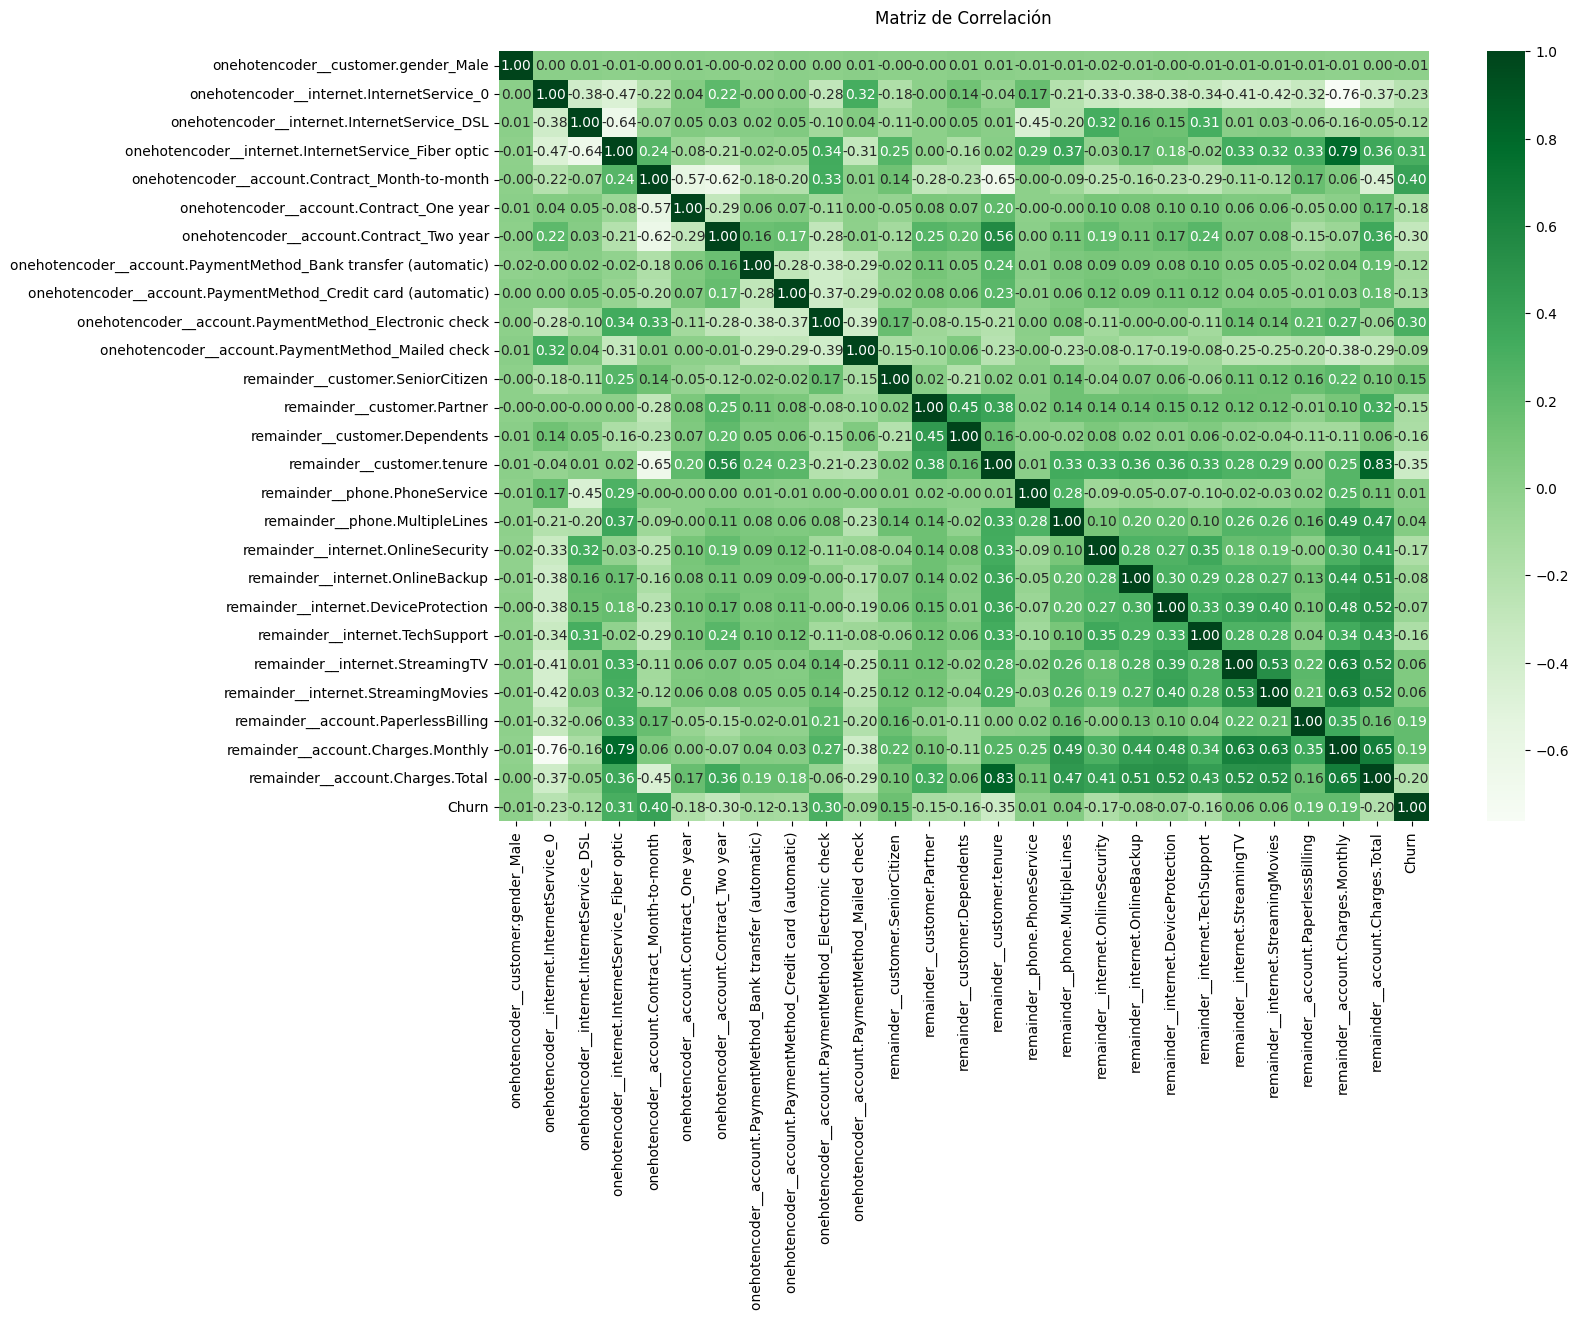

,Churn
Churn,1.000000
onehotencoder__account.Contract_Month-to-month,0.404565
onehotencoder__internet.InternetService_Fiber optic,0.307463
onehotencoder__account.PaymentMethod_Electronic check,0.301455
remainder__account.Charges.Monthly,0.192858
remainder__account.PaperlessBilling,0.191454
remainder__customer.SeniorCitizen,0.150541
remainder__internet.StreamingTV,0.063254
remainder__internet.StreamingMovies,0.060860
remainder__phone.MultipleLines,0.040033


In [ ]:
#Gráfica de correlación
plt.figure(figsize=(15,10))
sns.heatmap(pd.concat([X, y], axis = 1).corr(), cmap='Greens', annot = True, fmt = ".2f")
plt.title("Matriz de Correlación", pad=20)
plt.show()

pd.concat([X, y], axis=1).corr()['Churn'].sort_values(ascending=False)

**El heatmap (mapa de calor) es la forma más eficiente de leer una matriz de correlación cuando hay muchas variables, indica que cada variable tiene una correlación perfecta consigo misma, es decir 1.0:**

* **Colores intensos (1.0):** Indica una relación directa total, si una sube, la otra también.

* **Colores menos intensos (-1.0):** Indica una relación inversa perfecta, es decir, detectan variables que se comportan de forma opuesta.

* **Blanco o colores claros (0):** Indica que hay falta de relación lineal, por lo tanto, los cambios en una variable no ayudan en nada a predecir la otra.

## **Análisis Dirigido**

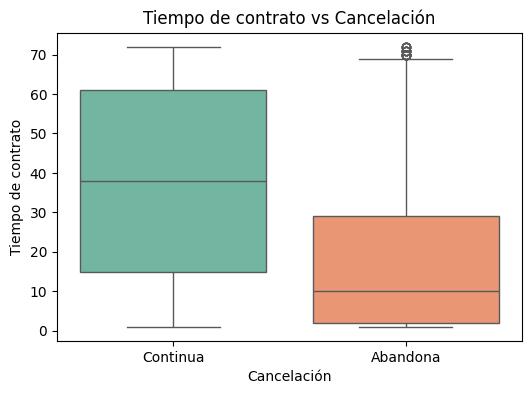

In [ ]:
# Gráfica de tiempo de contrato (ternure) vs cancelación (churn)
valores_churn = datos["Churn"].map({0:"Continua",1:"Abandona"})

plt.figure(figsize = (6,4))
sns.boxplot(data = datos, x = valores_churn,
            y = "customer.tenure",
            hue = valores_churn,
            palette = "Set2",
            )

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Tiempo de contrato")
plt.show()

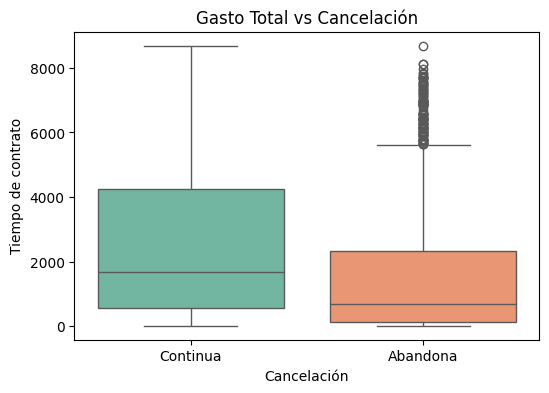

In [ ]:
# Gráfica de gasto total vs cancelación
valores_churn = datos["Churn"].map({0:"Continua",1:"Abandona"})

plt.figure(figsize = (6,4))
sns.boxplot(data = datos, x = valores_churn,
            y = "account.Charges.Total",
            hue = valores_churn,
            palette = "Set2",
            )
plt.title("Gasto Total vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Tiempo de contrato")
plt.show()

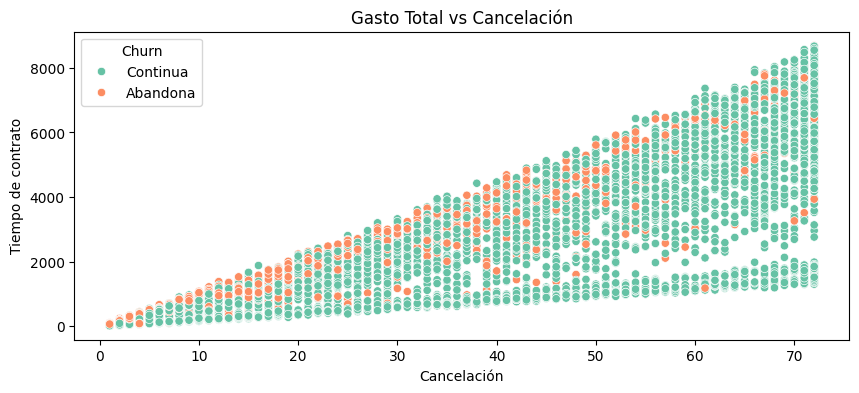

In [ ]:


valores_churn = datos["Churn"].map({0:"Continua",1:"Abandona"})

plt.figure(figsize = (10,4))
sns.scatterplot(data = datos, x = "customer.tenure",
            y = "account.Charges.Total",
            hue = valores_churn,
            palette = "Set2",
            )
plt.title("Gasto Total vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Tiempo de contrato")
plt.show()

# **3. 🤖 Modelado Predictivo**

## **Separación de datos**

In [ ]:
# Dividir los datos de prueba de los datos de entrenamiento
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state = 5)

y_train.value_counts(normalize=True)

,proportion
Churn,
0,0.734168
1,0.265832


**Se puede observar que hay un gran desbalance, por lo tanto, es necesario utilizar métodos de balanceo.**

## **Normalización**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

## **Balanceo**

**Oversampling Aleatorio**

In [ ]:
from imblearn.over_sampling import RandomOverSampler

over_sampling_aleatorio = RandomOverSampler(random_state=5)
X_train_over, y_train_over = over_sampling_aleatorio.fit_resample(X_train_scaler, y_train)

y_train_over.value_counts()

,count
Churn,
0,3872
1,3872


In [ ]:
y_train_over.value_counts(normalize = True)

,proportion
Churn,
0,0.5
1,0.5


**Oversampling SMOTE**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaler, y_train)

y_train_smote.value_counts()

,count
Churn,
0,3872
1,3872


In [ ]:
y_train_smote.value_counts(normalize = True)

,proportion
Churn,
0,0.5
1,0.5


**Undersamping**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

under_sampling = RandomUnderSampler(random_state = 5)
X_train_under, y_train_under = under_sampling.fit_resample(X_train_scaler, y_train)

y_train_under.value_counts()

,count
Churn,
0,1402
1,1402


In [ ]:
y_train_under.value_counts(normalize = True)

,proportion
Churn,
0,0.5
1,0.5


Se observa que se logró aplicar correctamente para todos métodos.

Se aumentó la clase minoritaria (1 / abandonó) hasta alcanzar la mayoritaria(0 / continúo), es decir, ambos tienen la misma cantidad de ejemplos, esto quiere decir que se confirma que el oversampling y undersampling se aplicaron correctamente.

### **Dummy Classifier**

Accuracy: 0.7343572241183163
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1291
           1       0.00      0.00      0.00       467

    accuracy                           0.73      1758
   macro avg       0.37      0.50      0.42      1758
weighted avg       0.54      0.73      0.62      1758

[[1291    0]
 [ 467    0]]


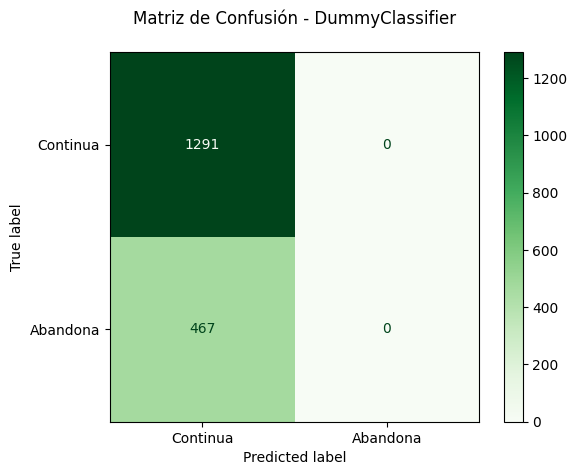

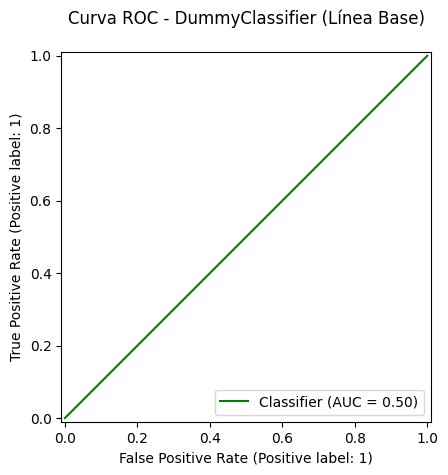

In [ ]:
# Modelo Dummy Classifier
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy = 'most_frequent')
dummy.fit(X_train_scaler, y_train)

y_pred_dummy = dummy.predict(X_test_scaler)

#Accuracy - qué porcentaje fueron correctas?
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
#Recall - cuántos clientes que sí se iban se detectaron
#F1 - qué tan equilibrado está el modelo entre precisión y recall
print(classification_report(y_test, y_pred_dummy))
#Falsos negativos - clientes que sí se iban y el modelo no detecto
print(confusion_matrix(y_test, y_pred_dummy))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_dummy)
visualizacion_dummy = ConfusionMatrixDisplay(confusion_matrix = cm,
                                             display_labels = ['Continua', 'Abandona'])

visualizacion_dummy.plot(cmap='Greens', values_format='d')
plt.title("Matriz de Confusión - DummyClassifier", pad = 20)
plt.show()

# Probabilidad curva ROC
y__pred_dummy_proba = dummy.predict_proba(X_test_scaler)[:,1]

# Curva ROC del modelo Dummy Classifier
RocCurveDisplay.from_predictions(y_test, y__pred_dummy_proba, color = 'Green')
plt.title('Curva ROC - DummyClassifier (Línea Base)', pad = 20)
plt.show()

El problema de este modelo es que no está "aprendiendo" patrones, solo está prediciendo que nadie abandonará la empresa, no sirve para detectar el riesgo.

Accuracy (73%) : Se observa que predice que el 73% de la base de datos son clientes leales, aunque estadicamente   

Recall (1.00) : Como el modelo marca a todos como "Leales" y no deja ninguno afuera, el problema es que no detecta cual cliente puede abandonar en algún futuro.

Al analizar la matriz de confusión se observa que:

* Identificó correctamente a los clientes que permanecen.
* Clasificó incorrectamente a 467 personas como "leales" a pesar de que abandonaron la empresa, estos son falsos negativos.
* El modelo no pudo identificar ni un caso real de abandono, estos son los verdaderos positivos.

AUC (0.50): Esto quiere decir que el modelo no logra identificar entre un cliente que abandona y otro que se queda, cualquier otro modelo que identifique al menos un cliente que abandone será superior al modelo Dummy.


## **Creación de modelos para comparación**

### **Regresión Logística**

Accuracy: 0.7343572241183163
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1291
           1       0.52      0.79      0.63       467

    accuracy                           0.75      1758
   macro avg       0.71      0.76      0.72      1758
weighted avg       0.80      0.75      0.76      1758



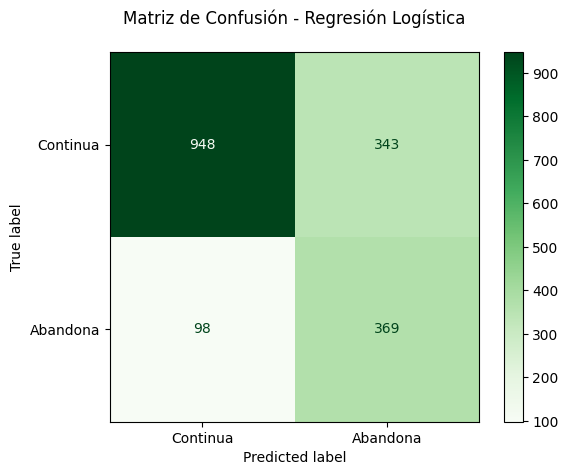

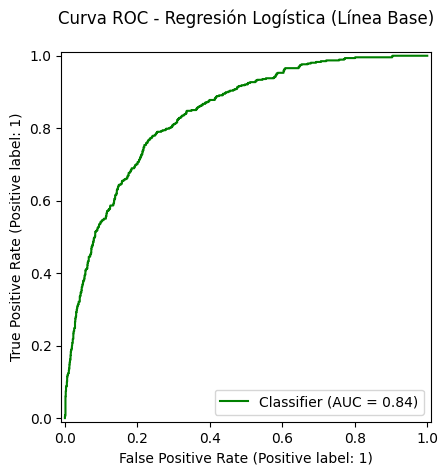

In [ ]:
#Modelo Regresión Lógistica
from sklearn.linear_model import LogisticRegression

#Crea el modelo
reg_log = LogisticRegression(max_iter = 2000, class_weight = None)

#Entrena el modelo
reg_log.fit(X_train_smote, y_train_smote)

#Predice el modelo
y_pred_reg_log = reg_log.predict(X_test_scaler)

#Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print(classification_report(y_test, y_pred_reg_log))

#Matriz de confusión
cm = confusion_matrix(y_test, y_pred_reg_log)
visualizacion_dummy = ConfusionMatrixDisplay(confusion_matrix = cm,
                                             display_labels = ['Continua', 'Abandona'])
#Gráfico
visualizacion_dummy.plot(cmap='Greens', values_format='d')
plt.title('Matriz de Confusión - Regresión Logística', pad = 20)
plt.show()

# probabilidad de clase 1 (Churn)
y_reg_log_proba = reg_log.predict_proba(X_test_scaler)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_reg_log_proba, color = 'Green')
plt.title('Curva ROC - Regresión Logística (Línea Base)', pad = 20)
plt.show()

A diferencia del modelo base, este logra distinguir entre clientes, es decir, ahora logra determinar muchos más casos de abandono, aunque muestra una tendencia muy alta.

Como este 84% (0.84) esta mucho más cerca de 1.0 que de 0.5, se confirma que el modelo aprendió patrones útiles para predecir la probabilidad de que un cliente abandone la empresa.

Con respecto a la Matriz de Confusión se puede observar que en este modelo hay:

* 948 clientes que en realidad permanecen en la empresa.
* 343 clientes que se predice que abandonan la empresa, pero en realidad se quedan. Falsos Positivos
* 369 clientes que en realidad abandonan la empresa.
* 98 clientes que se predice que se queda en la empresa, pero en realidad se van. Falsos Negativos.

En realidad el modelo de regresión logística si mejoró las predicciones con respecto al Dummy, se redujo significativamente el riesgo.

El valor de accuracy es el mismo que el de Dummy, pero el valor de este modelo es por mucho superior, ya que mientras que el de Dummy acertaba el 73% sin predecir solo memorizando, este modelo acierta el 73% identificando a la mayoría de los que sí se van.



### **Decision Tree**

Accuracy: 0.7912400455062572
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1291
           1       0.62      0.55      0.58       467

    accuracy                           0.79      1758
   macro avg       0.73      0.71      0.72      1758
weighted avg       0.78      0.79      0.79      1758



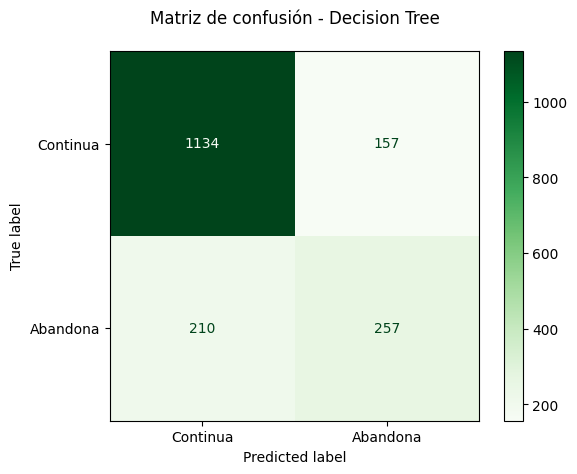

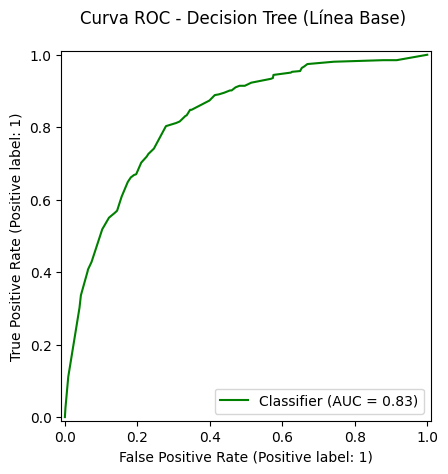

In [ ]:
# Modelo Decision Tree
from sklearn.tree import DecisionTreeClassifier

#Entrenar árbol de decisión podado
arbol_decision = DecisionTreeClassifier(max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=5
)

arbol_decision.fit(X_train_scaler, y_train)

#prediccion
y_arbol_decision = arbol_decision.predict(X_test_scaler)

#Métricas
print('Accuracy:', accuracy_score(y_test, y_arbol_decision))
print(classification_report(y_test, y_arbol_decision))

#Matriz de confusión
cm = confusion_matrix(y_test, y_arbol_decision)
visualizacion_dummy = ConfusionMatrixDisplay(confusion_matrix = cm,
                                             display_labels = ['Continua', 'Abandona'])

#Gráfico
visualizacion_dummy.plot(cmap = 'Greens')
plt.title('Matriz de confusión - Decision Tree', pad = 20)
plt.show()

#probabilidad curva ROC
y_arbol_decision_proba = arbol_decision.predict_proba(X_test_scaler)[:, 1]

#Curva ROC
RocCurveDisplay.from_predictions(y_test, y_arbol_decision_proba, color = 'Green')
plt.title('Curva ROC - Decision Tree (Línea Base) ', pad = 20)
plt.show()

Aunque el AUC bajó un poco (de 0.84 a 0.83), el modelo sigue siendo bastante confiable, tiene un 83% de probabilidad de identificar correctamente quién tiene mayor riesgo de abandono, por lo tanto, también logra predecir y no solo memorizar.

Con respecto a la Matriz de Confusión se puede observar que en este modelo hay:

* 1134 clientes que en realidad permanecen en la empresa.
* 157 clientes que se predice que abandonan la empresa, pero en realidad se quedan. Falsos positivos.
* 257 clientes que en realidad abandonan la empresa.
* 210 clientes que se predice que se queda en la empresa, pero en realidad se van. Falsos negativos.

En este caso, el aumento del Accuracy del 73% al 79% es importante porque el modelo está entendiendo mejor los datos.

### **Comparación de modelos**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

modelos = {
    'Dummy': dummy,
    'Regresión Logística': reg_log,
    'Decision Tree': arbol_decision }

resultados = []

for nombre, modelo in modelos.items():
    # Predicciones
    y_pred = modelo.predict(X_test_scaler)
    y_proba = modelo.predict_proba(X_test_scaler)[:, 1]

    # Métricas
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    })

# Convertir a DataFrame
df_comparacion = pd.DataFrame(resultados)
df_comparacion.round(2).style.highlight_max(
    subset=['Recall', 'AUC', 'F1-score'],
    color='#77dd77')

,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,Dummy,0.730000,0.000000,0.000000,0.000000,0.500000
1,Regresión Logística,0.750000,0.520000,0.790000,0.630000,0.840000
2,Decision Tree,0.790000,0.620000,0.550000,0.580000,0.830000


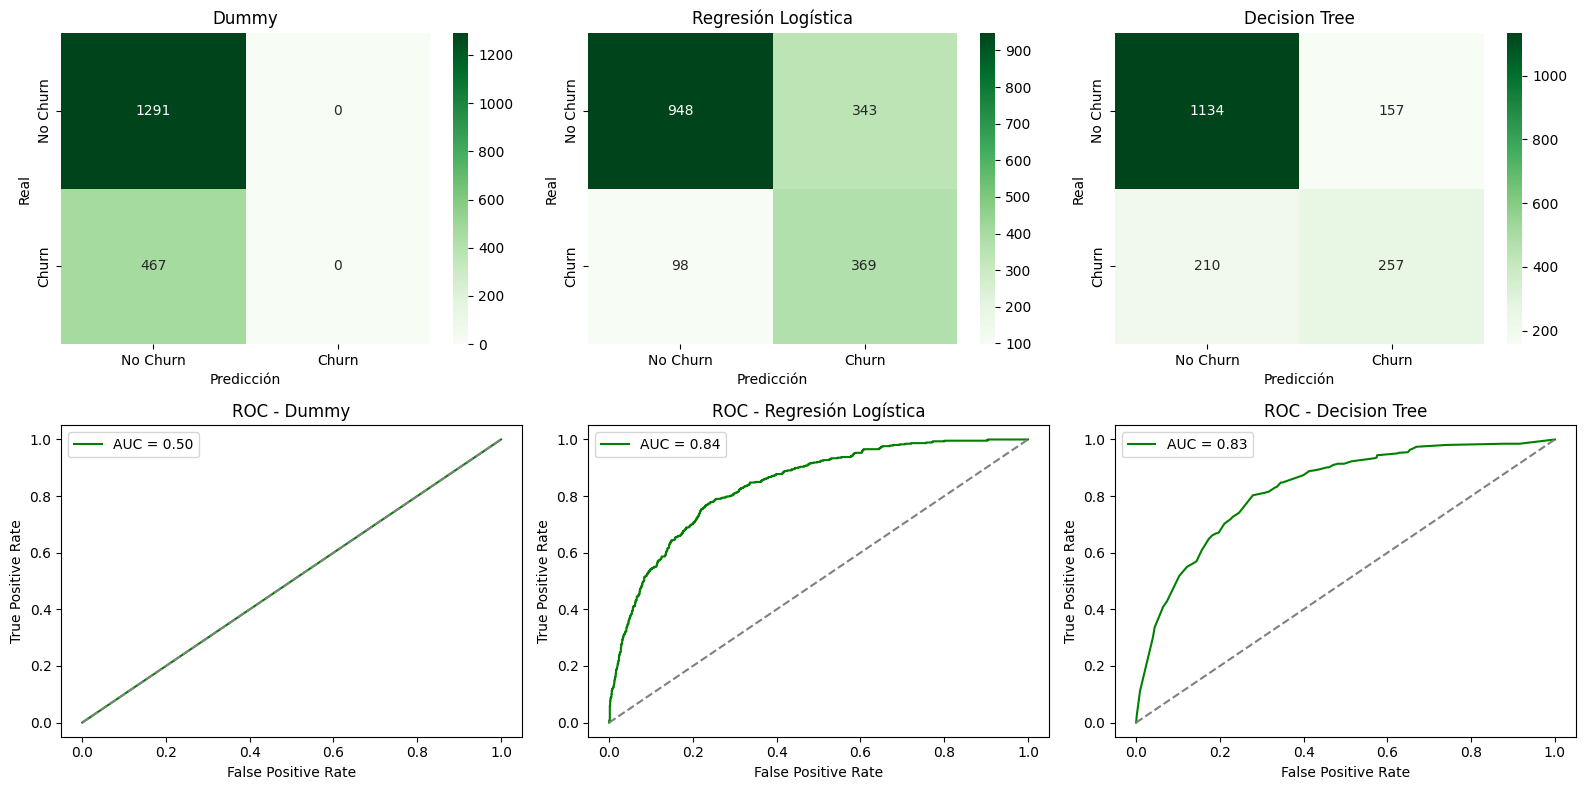

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

modelos = {
    'Dummy': dummy,
    'Regresión Logística': reg_log,
    'Decision Tree': arbol_decision,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.reshape(2, 3)

# Matrices de confusión
for idx, (nombre, modelo) in enumerate(modelos.items()):
    ax = axes[0, idx]

    y_pred = modelo.predict(X_test_scaler)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                ax=ax)
    ax.set_title(nombre)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")


# Curvas ROC
for idx, (nombre, modelo) in enumerate(modelos.items()):
    ax = axes[1, idx]  # fila 1, columna idx

    y_proba = modelo.predict_proba(X_test_scaler)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color='green', label=f"AUC = {roc_auc:.2f}")
    ax.plot([0,1], [0,1], linestyle='--', color='gray')
    ax.set_title(f"ROC - {nombre}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

plt.tight_layout()
plt.show()

Para atender bien el problema de abandono de clientes, es necesario saber a quien se le debe de prestar atención antes de que se vaya. Entonces vamos a analizar cada una de las métricas utilizadas y determinar cual es el mejor modelo.

1. Recall: Mide el porcentaje de clientes que realmente abandonan la empresa y que el modelo logró predecir, un Recall alto quiere decir que muy pocos clientes se escapan de ser acertados.

2. F1-Score: Es la métrica de armonía que combina accuracy y recall, esto asegura que el modelo esté balanceado y no se vaya demasiado a los extremos, evitando que se creen demasiados falsos positivos y negativos

3. AUC: Mide qué tan bien el modelo distingue a un cliente que se va de uno que se queda.

* 0.50 → modelo aleatorio
* 0.70 - 0.80 → aceptable
* 0.80 - 0.90 → muy bueno
* 0.90 + → excelente

**Por lo tanto, el modelo que mejor se adapta a nuestro conjunto de datos es Regresión Logística.**

# **4. 📋 Interpretación y Conclusiones**

## **Análisis de la Importancia de las Variables**

Regresión Logística: El signo dice hacia dónde se mueve el riesgo.

* Signo Positivo: Si el valor de la variable sube, también crece la probabilidad de que el cliente abandone.

* Signo Negativo: Si el valor de la variable sube, la probabilidad de abandono disminuye.

* El 0 es el punto neutro, es la ausencia de empuje.


In [ ]:
#Importancia de variables es Regresión Logístia

coeficientes = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': reg_log.coef_[0]
}).sort_values(by = 'Coeficiente', ascending = False)

coeficientes

,Variable,Coeficiente
25,remainder__account.Charges.Total,0.856265
3,onehotencoder__internet.InternetService_Fiber ...,0.697965
4,onehotencoder__account.Contract_Month-to-month,0.335903
22,remainder__internet.StreamingMovies,0.279181
21,remainder__internet.StreamingTV,0.256056
16,remainder__phone.MultipleLines,0.242595
23,remainder__account.PaperlessBilling,0.199828
9,onehotencoder__account.PaymentMethod_Electroni...,0.130828
19,remainder__internet.DeviceProtection,0.054014
7,onehotencoder__account.PaymentMethod_Bank tran...,0.043948


Decision Tree:
En un Árbol de Decisión, la métrica no tiene signo y siempre es un valor entre 0 y 1. La importancia solo muestra qué tan útil fue esa variable para separar a los clientes, no importa si esa separación fue porque la variable era alta o baja. Un 0 significa que el árbol no necesitó preguntar por esa variable para tomar una decisión.


In [ ]:
#Importancia de variables es Decision Tree

importancia_decision_tree = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': arbol_decision.feature_importances_
}).sort_values(by = 'Coeficiente', ascending = False)

importancia_decision_tree

,Variable,Coeficiente
4,onehotencoder__account.Contract_Month-to-month,0.492384
14,remainder__customer.tenure,0.166296
3,onehotencoder__internet.InternetService_Fiber ...,0.128339
24,remainder__account.Charges.Monthly,0.053794
25,remainder__account.Charges.Total,0.049092
9,onehotencoder__account.PaymentMethod_Electroni...,0.027564
2,onehotencoder__internet.InternetService_DSL,0.017296
23,remainder__account.PaperlessBilling,0.015509
16,remainder__phone.MultipleLines,0.013800
15,remainder__phone.PhoneService,0.007934


## **Conclusiones**

Luego de realizar el análisis de los modelos, se identificaron los principales factores que provocan la cancelación del servicio, entre ellos están:

El tipo de contrato determina el riesgo de abandono para la empresa:

* Riegoso: Los contratos de renovación mensual presentan la tasa de abandono más alta.
* Seguro: Los contratos a largo plazo muestran los niveles de abandono más bajos, luego de 2 años es muy poco probable que esto suceda.

Hay una relación directa entre el tiempo de permanencia y la lealtad, los clientes nuevos tienden a desertar antes de crear una relación con la empresa.

Los altos cargos mensuales y totales, motiva a los clientes buscar mejores opciones en la competencia lo que genera un aumento en la deserción.



El Paradox de la Fibra Óptica: A pesar de ser una tecnología superior, los clientes con Fibra Óptica muestran una mayor propensión al abandono. Esto sugiere áreas de mejora en:

Competitividad de precios frente a otras tecnologías.
Estabilidad técnica del servicio o expectativas no cumplidas.
Fricciones en los tiempos de instalación o soporte post-venta.

Por lo tanto, un cliente con poco tiempo en la empresa que adquiere un contrato mensual por servicio el de fibra óptica (cargo más elevado), tiene la probabilidad más alta de cancelar el servicio.